## Support Vector Machine

Shape of X: (1797, 64)
Shape of y: (1797,)


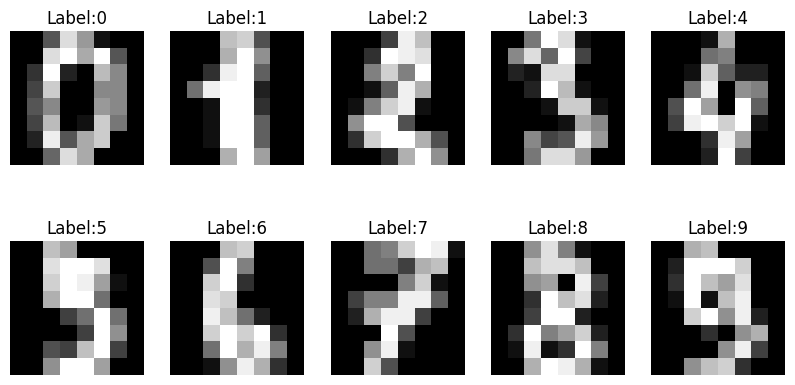

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits=load_digits()
X=digits.data    #type: ignore
y=digits.target  #type: ignore

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


# Show sample images
fig, axes=plt.subplots(2,5, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label:{y[i]}")
    ax.axis("off")
    
plt.show()

In [2]:
# Data Exploration

import numpy as np

print("Number of samples:", len(X))
print("Number of features:", X.shape[1])

#Class distribution
unique, counts=np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))


Number of samples: 1797
Number of features: 64
{np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}


In [3]:
# Train-test Split + Scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [4]:
# Train SVM (Linear Kernel)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm_linear=SVC(kernel="linear")
svm_linear.fit(X_train_scaled, y_train)

y_pred=svm_linear.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.94      0.97      0.96        34
           4       1.00      1.00      1.00        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       1.00      0.93      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360



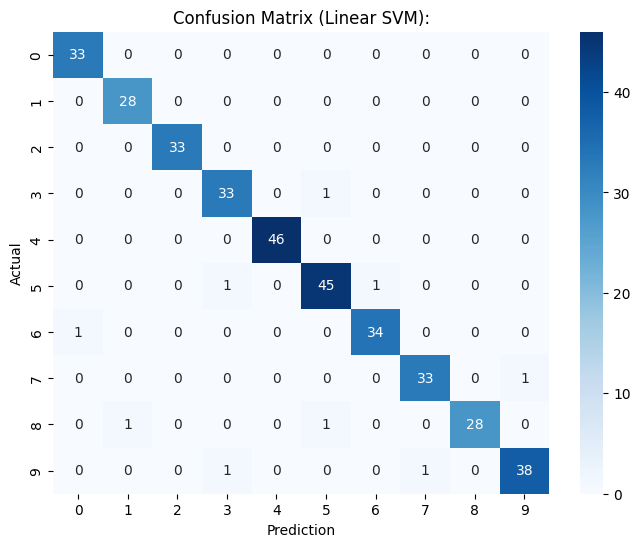

In [5]:
# Confusion Matrix

import seaborn as sns

cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Linear SVM):")
plt.show()

In [6]:
#Polynomial
svm_poly=SVC(kernel="poly", degree=3)
svm_poly.fit(X_train_scaled, y_train)
poly_pred=svm_poly.predict(X_test_scaled)

#RBF
svm_rbf=SVC(kernel="rbf")
svm_rbf.fit(X_train_scaled, y_train)
rbf_pred=svm_rbf.predict(X_test_scaled)

print("Poly Accuracy:", accuracy_score(y_test, poly_pred))
print("RBF Accuracy:", accuracy_score(y_test, rbf_pred))

Poly Accuracy: 0.9638888888888889
RBF Accuracy: 0.9805555555555555


In [7]:
# Hyperparameter Tuning (GridSearchCV)

from sklearn.model_selection import GridSearchCV

param_grid={
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3]  # only used for poly
}

grid=GridSearchCV(SVC(), param_grid, cv=3, verbose=2, n_jobs=2)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_
best_pred = best_model.predict(X_test_scaled)

print("Best Accuracy:", accuracy_score(y_test, best_pred))


Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ..........C=0.1, degree=2, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ..........C=0.1, degree=2, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ..........C=0.1, degree=2, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=0.01, kernel=poly; total time=   0.1s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=0.01, kernel=poly; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=0.01

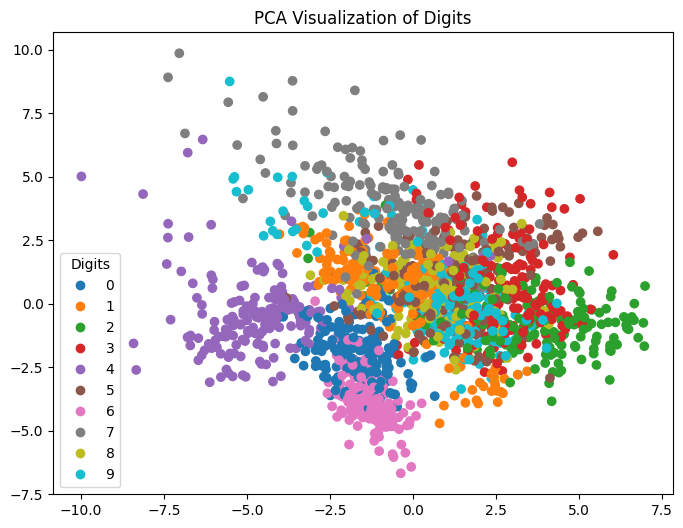

In [8]:
# PCA Visualization (2D)

from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled:=scaler.fit_transform(X))

plt.figure(figsize=(8, 6))
scatter=plt.scatter(X_pca[:,0], X_pca[:, 1], c=y, cmap="tab10")
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("PCA Visualization of Digits")
plt.show()

In [9]:
# Compare with Logistic Regression

from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

log_pred=log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.9722222222222222
